# Assignment 5: Replication Attempt

## Submitting the assignment

1. When you are done, rename this Colab file to HW5 \<username\>, eg "HW5 deb219".
1. Then _**share**_ it with me (deb219@lehigh.edu) by clicking the big Share button in the upper right of this page.
1. And upload it to coursesite under HW5 for record keeping.

**I'll subtract points for not doing any these things.**

## Pre-requisites

- Normalized data lecture (08)
- Merging lecture (09), especially its Good Habits and Most Common Merging Parameters section

## Learning goals:

- Practice putting the merging habits to use
- Computing variables at the right observation level

## Time expectations

Get it done!


# Live coding: Replicating a paper

The goal today is to build the codebase needed replicate some key findings from "The Market’s Mirror: Revealing Disagreement with LLMs", a new working paper by Bhagwat et al.

In class, I assembled the core pieces of the code below. It ran, and was a small section of code from producing a correlation!

After class, I spent an hour to make it more robust
- Firms only repicked if desired
- Headlines only downloaded again if desired (or if we have a new list of firms)
- Survey results can be reloaded to save time
- Code structure cleaned (all imports at top, markdown text helps)
- Then I reran the survey with the parameters you see here
    - It surveyed 20 LLM "people" on ~1,200 headlines for ~23,000 survey answers
    - It took 30 minutes
    - It cost $1 dollar



In [1]:
! uv pip install edsl feedparser -q # uv is a fast Python package installer (written in Rust)

In [2]:
import os
import datetime as dt
import numpy as np
import pandas as pd
import pandas_datareader as pdr
import requests
import feedparser
import math
import time
import random
import re
import yfinance as yf
from typing import Iterable, Union, Tuple, Dict, Any, List
from tqdm import tqdm
import yfinance as yf
from datetime import datetime, timedelta
from bs4 import BeautifulSoup
from edsl import QuestionFreeText, ScenarioList, Scenario, Model, Agent
from edsl import AgentList, Results
from google.colab import userdata
from google.colab import drive
from io import StringIO

os.environ['EXPECTED_PARROT_API_KEY'] = userdata.get('EXPECTED_PARROT_API_KEY')

# File in/out access
drive.mount('/content/drive')

# EDSL model
# pricing here: https://www.expectedparrot.com/models
# they use temp=0 in the paper.

m = Model("gemini-2.0-flash-lite", parameters = {'max_tokens':10, 'temperature':0.2})
m

Mounted at /content/drive


key,value
model,gemini-2.0-flash-lite
parameters:max_tokens,10
parameters:temperature,0.2
inference_service,google


## Inputs


In [3]:
# Where to put the files
save_dir = file_path = f'/content/drive/MyDrive/Colab Notebooks/Spr26 My Fin377 Solutions and Notes During Class/EDSL Repliciation/data/'
os.makedirs(save_dir, exist_ok=True)

# firms and headline parameters
TEST_LIMIT_FIRMS = 20        # Set to 20-50 while developing code and you'll only use the first TEST_LIMIT_FIRMS in the sp500 list. Set to None to use all firms in the SP500.
force_new_firms = False       # If false, will use previous data. You need to set this to true to get new firms after Dev experiments!
force_new_headlines = False  #
LOOKBACK_DAYS = 90           # how many days of headlines to get

# survey parameters
MAX_HEADLINES_PER_MONTH = 20 # put to None to use all articles (100 a month)
num_agents = 20              # survey size
prior_result_uuid = "ea6d10a2-f63c-41d1-8c99-e91a497cefb6" #
                             # You can reload prior survey results with a numeric ID from the
                             # go to https://www.expectedparrot.com/home/remote-inference
                             # find the job you want, click on the "View" button to see the progress report,
                             # then click Pull, then copy the string from inside the Pull code, e.g.:
                             # You see: results = Results.pull("b6bc0835-0fd8-488b-b560-1ab686a59ace")
                             # Put prior_result_uuid = "b6bc0835-0fd8-488b-b560-1ab686a59ace"



In [4]:
# we will run N surveys:
TEST_LIMIT_FIRMS*MAX_HEADLINES_PER_MONTH*num_agents*(LOOKBACK_DAYS//30)

24000

## Get a list of sample firms

In [5]:
save_file = save_dir + 'sp500.csv'

if not os.path.exists(save_file) or force_new_firms:

    # URL of the Wikipedia page with the S&P 500 list
    sp500_url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

    # (this is an extra line we have to do while running on colab. on your own computer, pd.read_html(url) works
    # get the html from the page, and use headers to bypass blocks
    response = requests.get(sp500_url, headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'})

    # then give the html to pandas
    sp500_df = pd.read_html(response.text)[0]

    # display(sp500_df.head()) # display() makes these dataframes print nicer than print

    # Ask gemini to explain this to you! Add the answers as a column
    if TEST_LIMIT_FIRMS:
        sp500_df = sp500_df.sample(n=TEST_LIMIT_FIRMS,replace=False,random_state=50)
        sp500_df = sp500_df.sort_values(['Symbol'])

    # set up tickers to match yfinance (. -> -)
    sp500_df['Symbol'] = sp500_df['Symbol'].str.replace('.', '-')

    sp500_df.to_csv(save_file, index=False)

# Load the data
sp500_df = pd.read_csv(save_file)
display(sp500_df)

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,AMCR,Amcor,Materials,Paper & Plastic Packaging Products & Materials,"Warmley, Bristol, United Kingdom",2019-06-07,1748790,2019 (1860)
1,COP,ConocoPhillips,Energy,Oil & Gas Exploration & Production,"Houston, Texas",1957-03-04,1163165,2002
2,GEV,GE Vernova,Industrials,Heavy Electrical Equipment,"Cambridge, Massachusetts",2024-04-02,1996810,2024
3,GS,Goldman Sachs,Financials,Investment Banking & Brokerage,"New York City, New York",2002-07-22,886982,1869
4,INVH,Invitation Homes,Real Estate,Single-Family Residential REITs,"Dallas, Texas",2022-09-19,1687229,2012
5,LYB,LyondellBasell,Materials,Specialty Chemicals,"Rotterdam, Netherlands",2012-09-05,1489393,2007
6,NWS,News Corp (Class B),Communication Services,Publishing,"New York City, New York",2015-09-18,1564708,2013 (News Corporation 1980)
7,PAYX,Paychex,Industrials,Human Resource & Employment Services,"Penfield, New York",1998-10-01,723531,1971
8,PCAR,Paccar,Industrials,Construction Machinery & Heavy Transportation ...,"Bellevue, Washington",1980-12-31,75362,1905
9,PGR,Progressive Corporation,Financials,Property & Casualty Insurance,"Mayfield Village, Ohio",1997-08-04,80661,1937


## GET HEADLINES

Lightly adapted from the GPT Hedge fund project to create a dataset.

I learned a lot from EDA - the headlines from the Google RSS feed are often unrelated to the firm! Cardi B showed up in a bunch.

Below, we clean it up a bit by requiring the headline to have the exact ticker, in uppercase, as a stand alone word. This is an improvement--no more Cardi B headlines, but still not the best. A professional grade solution like stocknewsapi.com or RavenPack (expensive!) that pre-cleans headlines would be better.


In [6]:
if force_new_firms:
    force_new_headlines = True # if you get new firms, you need headlines to match

In [7]:
# gemini prompt 1: Where this function prints, let's instead add to an output variable. The function should return the total text as an object that can be printed.
# gemini prompt 2: Let's make a wrapper function that takes a ticker and a lookback length. The url's date portions are modified based on lookback length

def get_headlines_from_rss(rss_url, ticker):
    """Fetches and returns headlines as a string from a given RSS feed URL."""
    feed = feedparser.parse(rss_url)
    headlines_list = []

    if feed.entries:
        for entry in feed.entries:
            # Convert struct_time to datetime object, then format
            published_date = datetime(*entry.published_parsed[:6])
            headlines_list.append({
                'Ticker': ticker,
                'Date': published_date.strftime('%Y-%m-%d'),
                'Headline': entry.title
            })
    else:
        print(f"Could not fetch headlines from {rss_url} or no entries found.\n")

    return pd.DataFrame(headlines_list)


def generate_google_news_rss_url(ticker, start_date,end_date):
    """Generates a Google News RSS feed URL for a given ticker and lookback period."""

    end_date_str = end_date.strftime('%Y-%m-%d')
    start_date_str = start_date.strftime('%Y-%m-%d')

    # Construct the URL with ticker and date range
    rss_url = f'https://news.google.com/rss/search?q={ticker}+after:{start_date_str}+before:{end_date_str}&ceid=US:en&hl=en-US&gl=US'
    return rss_url

# print(get_headlines_from_rss(generate_google_news_rss_url("business",30)))

Example use of functions:

In [8]:
start_date = datetime.now() - timedelta(days=30)
end_date = datetime.now()
print(get_headlines_from_rss(generate_google_news_rss_url("APPL",start_date,end_date), "AAPL"))

   Ticker        Date                                           Headline
0    AAPL  2026-02-01  Christina Pier & Benjamin Appl Lead Sun Valley...
1    AAPL  2026-03-01  Signs, Games, and Messages 2026 - Program One ...
2    AAPL  2026-02-14  First-of-its-kind automated root imaging platf...
3    AAPL  2026-02-03  Snappt Releases 2026 Multifamily Fraud Report,...
4    AAPL  2026-02-14  Universe Saturn Patches Iron On Embroidered Pa...
5    AAPL  2026-02-19  Scientists empower an AI foundation model to a...
6    AAPL  2026-02-13  Novel Root Imaging Platform Accelerates Plant ...
7    AAPL  2026-02-25  Apple shareholders reject call for report on C...
8    AAPL  2026-02-07  Inside Germany's Booming City | Hamburg's Urba...
9    AAPL  2026-02-20  Integris Medtech, APPL Containers among 4 othe...
10   AAPL  2026-02-20  Integris Medtech, Anjali Labtech, APPL Contain...
11   AAPL  2026-02-27                 Angelica Ysla - Sports Illustrated
12   AAPL  2026-02-01  Budget 2026 boosts container

Now, grab the data for real.

In [9]:
save_file = save_dir + 'headlines_downloaded.csv'
not os.path.exists(save_file) or force_new_headlines

False

In [10]:
save_file = save_dir + 'headlines_downloaded.csv'

if not os.path.exists(save_file) or force_new_headlines:

    all_headlines_df = pd.DataFrame()
    end_date = datetime.now()
    start_date = end_date - timedelta(days=LOOKBACK_DAYS) #

    # Create a list of months within the two-year period
    months = []
    current_date = start_date
    while current_date <= end_date:
        months.append(current_date)
        # Move to the next month
        if current_date.month == 12:
            current_date = current_date.replace(year=current_date.year + 1, month=1, day=1)
        else:
            current_date = current_date.replace(month=current_date.month + 1, day=1)

    # Iterate through the first X firms in sp500_df
    for index, row in sp500_df.head(TEST_LIMIT_FIRMS).iterrows():
        ticker = row['Symbol']
        # Iterate through each month and fetch headlines
        for month_start_date in tqdm(months, desc=f"Fetching headlines for {ticker}"):
            # Calculate the end date for the current month
            if month_start_date.month == 12:
                month_end_date = month_start_date.replace(year=month_start_date.year + 1, month=1, day=1) - timedelta(days=1)
            else:
                month_end_date = month_start_date.replace(month=month_start_date.month + 1, day=1) - timedelta(days=1)

            rss_url = generate_google_news_rss_url(ticker, month_start_date, month_end_date)
            headlines_df = get_headlines_from_rss(rss_url, ticker)
            all_headlines_df = pd.concat([all_headlines_df, headlines_df], ignore_index=True)

    # delete duplicate headlines
    all_headlines_df = all_headlines_df.drop_duplicates(subset=['Ticker', 'Date', 'Headline'])

    # require the headline to have the ticker with complete word and case matching
    all_headlines_df = all_headlines_df[all_headlines_df.apply(lambda row: re.search(r'\b' + re.escape(row['Ticker']) + r'\b', row['Headline']) is not None, axis=1)]

    # if a headline occurs multiple days for a firm, keep the first only
    all_headlines_df.sort_values(['Ticker', 'Headline', 'Date']).groupby(['Ticker', 'Headline']).head(1)

    print('\n\n\n==============================\n\n\n')

    display(all_headlines_df)

    all_headlines_df.sort_values(['Ticker','Date','Headline']).to_csv(save_file, index=False)

# Load the data
all_headlines_df = pd.read_csv(save_file)
display(all_headlines_df)

,Ticker,Date,Headline
0,AMCR,2025-12-04,Assessing Amcor (NYSE:AMCR) Valuation After It...
1,AMCR,2025-12-09,Amcor plc (AMCR): A Bull Case Theory - Yahoo F...
2,AMCR,2025-12-11,Amcor (AMCR) Announces 1-for-5 Reverse Stock S...
3,AMCR,2025-12-15,Insider Purchase: Executive VP of $AMCR Buys 1...
4,AMCR,2025-12-15,Is Amcor’s (AMCR) Reverse Stock Split Quietly ...
...,...,...,...
2981,WMT,2026-02-25,How Investors Are Reacting To Walmart (WMT) Bo...
2982,WMT,2026-02-25,"Insider Sale: 10% owner at $WMT Sells 3,734 Sh..."
2983,WMT,2026-02-25,TD Cowen Raises Walmart (WMT) Price Target to ...
2984,WMT,2026-02-25,Why Walmart’s (WMT) Stability Attracts Shrewd ...


### EDA on news data

<Axes: xlabel='Date'>

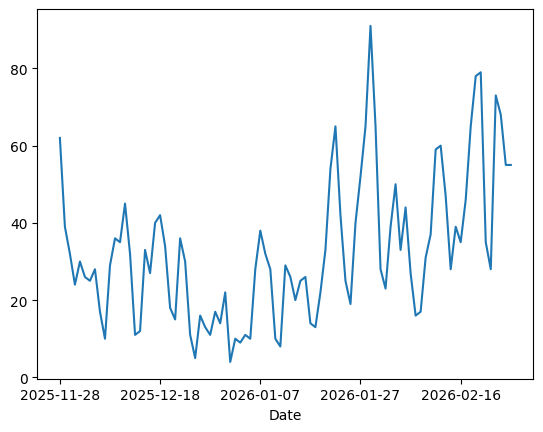

In [11]:
# plot the count of headlines in the df over time
all_headlines_df.value_counts('Date').sort_index().plot()


In [12]:
len(all_headlines_df)

2986

In [13]:
# any duplicate headlines?
int(all_headlines_df['Headline'].duplicated().sum())

23

In [14]:
# what do they say
all_headlines_df['Headline'].value_counts()

,count
Headline,
Goldman Sachs (GS) Surpasses Market Returns: Some Facts Worth Knowing - Yahoo Finance,3
"PayPal Holdings, Inc. (PYPL) is Attracting Investor Attention: Here is What You Should Know - Yahoo Finance",3
Truist Financial Maintains Charles Schwab(SCHW.US) With Buy Rating - 富途牛牛,2
Goldman Sachs (GS) Rises Higher Than Market: Key Facts - Yahoo Finance,2
Here's Why The Charles Schwab Corporation (SCHW) is a Strong Value Stock - Yahoo Finance,2
...,...
Earnings To Watch: Paychex (PAYX) Reports Q4 Results Tomorrow - Yahoo Finance,1
"PAYCHEX Q2 2026 Earnings Preview: Recent $PAYX Insider Trading, Hedge Fund Activity, and More - Quiver Quantitative",1
PAYX Q4 Deep Dive: AI Investments and Paycor Integration Shape Outlook Amid Margin Pressures - Yahoo Finance,1


## Run LLM surveys

### DEVELOPMENT HACK - just keep some data

Only keep X stories per month per firm. Note: This is random sampling, so you will get different results than I do.

In [15]:
all_headlines_df['Month'] = pd.to_datetime(all_headlines_df['Date']).dt.to_period('M')


In [16]:
MAX_HEADLINES_PER_MONTH = 200 if MAX_HEADLINES_PER_MONTH == None else MAX_HEADLINES_PER_MONTH

sampled_headlines_df = (all_headlines_df
                        .groupby(['Ticker', 'Month'])
                        # grab that many articles, but if there aren't that many, grab all of them
                        # replace = false means that after we draw a random article, we can't draw it again
                        # (the row is not "replaced" back in the sample to draw from)
                        .apply(lambda x: x.sample(n=min(MAX_HEADLINES_PER_MONTH, len(x)), replace=False, random_state=42)).reset_index(drop=True)
)
display(sampled_headlines_df)


/tmp/ipykernel_296/3559921136.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(MAX_HEADLINES_PER_MONTH, len(x)), replace=False, random_state=42)).reset_index(drop=True)


,Ticker,Date,Headline,Month
0,AMCR,2025-12-04,Assessing Amcor (NYSE:AMCR) Valuation After It...,2025-12
1,AMCR,2025-12-09,Amcor plc (AMCR): A Bull Case Theory - Yahoo F...,2025-12
2,AMCR,2025-12-18,(AMCR) Risk Channels and Responsive Allocation...,2025-12
3,AMCR,2025-12-11,Amcor (AMCR) Announces 1-for-5 Reverse Stock S...,2025-12
4,AMCR,2025-12-15,Is Amcor’s (AMCR) Reverse Stock Split Quietly ...,2025-12
...,...,...,...,...
1136,WMT,2026-02-14,"Walmart Inc. (NASDAQ:WMT) Passes the ""Caviar C...",2026-02
1137,WMT,2026-02-23,WMT's U.S. Segment Momentum: Are 4.6% Comp Sal...,2026-02
1138,WMT,2026-02-20,Walmart Q4 Results: A Rare Miss On Earnings Ou...,2026-02
1139,WMT,2026-02-19,Retailer for all: Walmart adds market share wi...,2026-02


In [17]:
all_headlines_df = sampled_headlines_df # this is sort of silly coding, but it means that we can delete these 3 cells sampling the data down again and all the rest of the code would work

### Make a panel of fake people



In [18]:
sex = ["male", "female"]
race = ["white", "black", "hispanic"]
age = ["18-34","35-54","55+"]
education = [
    "did not finish a college degree",
    "finished college"
]
income = [
    "under $50,000",
    "$50,000 to $99,999",
    "$100,000 or more",
]
political_ideology = ["liberal", "independent", "conservative"]

# how many possible combinations?
print(len(sex) * len(race) * len(age) * len(education) * len(income) * len(political_ideology))

324


In [19]:
def generate_random_agents(num_agents):
    '''
    Each simulated agent will have random traits. Notes:
    1. random.choice() chooses from a list with equal probability.
       You can switch to random.choices(race, weights = [50,15,35])
       to specify more realistic draws. random.choices, not random.choice
    2. I did not set a "seed" here - every time we run this, it gets a
       new result. This is fine for experimenting, but bad for replication.
       Ask Gemini to set a seed so you always get the same result.
    '''
    agents = []
    for _ in range(num_agents):
        agent_traits = {
            "sex": random.choice(sex),
            "race": random.choice(race),
            "age": random.choice(age),
            "education": random.choice(education),
            "income": random.choice(income),
            "political_ideology": random.choice(political_ideology),
        }
        agents.append(Agent(traits=agent_traits,
                            traits_presentation_template = " I am {{ age }} years-old {{ race }} {{ sex }} who {{ education }}. I make {{ income }} per year and am politically {{ political_ideology }}."
        ))

    return AgentList(agents)

Now, actually, make those people.

In [20]:
agents = generate_random_agents(num_agents)

In [21]:
# ABCD! always be checking your data

# Show an agent's prompt to check
a = agents[0]
a.agent_persona.render(primary_replacement = a.traits).text

' I am 18-34 years-old hispanic male who finished college. I make $100,000 or more per year and am politically independent.'

### Design the survey

It's one question with placeholders, but we

In [22]:
from edsl import QuestionNumerical, QuestionFreeText, ScenarioList, Scenario, Survey

q1 = QuestionNumerical(
    question_name = 'Sentiment',
    question_text = '''Take on that person's likely worldview, communication style, and financial expertise.

As this person,  how would you interpret the effect of the following financial news on the company's stock price?

HEADLINE: {{ headline }}
COMPANY: {{ company }}
DATE: {{ date }}

Provide a sentiment score from 1 (very negative) to 10 (very positive) about the company's future stock price based on your interpretation of the article.'''
)

survey = Survey(questions = [q1])

scenarios = ScenarioList([
    Scenario({"headline":  row['Headline'],
     "company": row['Ticker'],
     'date': row['Date']}) for index, row in all_headlines_df.iterrows()
]
)



In [23]:
scenarios[10] # abcd

key,value
headline,Is Amcor (AMCR) Offering An Opportunity After Recent Share Price Rebound? - Yahoo Finance
company,AMCR
date,2026-01-30


In [24]:
job = q1.by(scenarios).by(agents).by(m)

Check that the prompts look right:

In [25]:
q1.by(scenarios[:5]).by(agents).by(m).prompts()

user_prompt,system_prompt,interview_index,question_name,scenario_index,agent_index,model,estimated_cost,cache_keys
"Take on that person's likely worldview, communication style, and financial expertise. As this person, how would you interpret the effect of the following financial news on the company's stock price? HEADLINE: Assessing Amcor (NYSE:AMCR) Valuation After Its Recent 6% One-Month Share Price Rebound - Yahoo Finance COMPANY: AMCR DATE: 2025-12-04 Provide a sentiment score from 1 (very negative) to 10 (very positive) about the company's future stock price based on your interpretation of the article. This question requires a numerical response in the form of an integer or decimal (e.g., -12, 0, 1, 2, 3.45, ...). Respond with just your number on a single line. If your response is equivalent to zero, report '0' After the answer, put a comment explaining your choice on the next line.","You are answering questions as if you were a human. Do not break character. I am 18-34 years-old hispanic male who finished college. I make \$100,000 or more per year and am politically independent.",0,Sentiment,0,0,gemini-2.0-flash-lite,7.432499999999999e-05,['ceb93a19b0618fea5094b0496cbf5727']
"Take on that person's likely worldview, communication style, and financial expertise. As this person, how would you interpret the effect of the following financial news on the company's stock price? HEADLINE: Amcor plc (AMCR): A Bull Case Theory - Yahoo Finance COMPANY: AMCR DATE: 2025-12-09 Provide a sentiment score from 1 (very negative) to 10 (very positive) about the company's future stock price based on your interpretation of the article. This question requires a numerical response in the form of an integer or decimal (e.g., -12, 0, 1, 2, 3.45, ...). Respond with just your number on a single line. If your response is equivalent to zero, report '0' After the answer, put a comment explaining your choice on the next line.","You are answering questions as if you were a human. Do not break character. I am 18-34 years-old hispanic male who finished college. I make \$100,000 or more per year and am politically independent.",1,Sentiment,1,0,gemini-2.0-flash-lite,7.035e-05,['0b54404894c116f359c27488f807f032']
"Take on that person's likely worldview, communication style, and financial expertise. As this person, how would you interpret the effect of the following financial news on the company's stock price? HEADLINE: (AMCR) Risk Channels and Responsive Allocation - Stock Traders Daily COMPANY: AMCR DATE: 2025-12-18 Provide a sentiment score from 1 (very negative) to 10 (very positive) about the company's future stock price based on your interpretation of the article. This question requires a numerical response in the form of an integer or decimal (e.g., -12, 0, 1, 2, 3.45, ...). Respond with just your number on a single line. If your response is equivalent to zero, report '0' After the answer, put a comment explaining your choice on the next line.","You are answering questions as if you were a human. Do not break character. I am 18-34 years-old hispanic male who finished college. I make \$100,000 or more per year and am politically independent.",2,Sentiment,2,0,gemini-2.0-flash-lite,7.155e-05,['3f746c80e346e663e445065982494c89']
"Take on that person's likely worldview, communication style, and financial expertise. As this person, how would you interpret the effect of the following financial news on the company's stock price? HEADLINE: Amcor (AMCR) Announces 1-for-5 Reverse Stock Split - GuruFocus COMPANY: AMCR DATE: 2025-12-11 Provide a sentiment score from 1 (very negative) to 10 (very positive) about the company's future stock price based on your interpretation of the article. This question requires a numerical response in the form of an integer or decimal (e.g., -12, 0, 1, 2, 3.45, ...). Respond with just your number on a single line. If your response is equivalent to zero, report '0' After the answer, put a comment explaining your choice on the next l

In [26]:
job.estimate_job_cost()


{'estimated_total_cost_usd': 1.6693224000000089,
 'total_credits_hold': 166.94,
 'estimated_total_input_tokens': 5555828,
 'estimated_total_output_tokens': 4175451,
 'detailed_costs': [{'inference_service': 'google',
   'model': 'gemini-2.0-flash-lite',
   'token_type': 'input',
   'price_per_million_tokens': 0.075,
   'tokens': 5555828,
   'cost_usd': 0.4166871000000098,
   'credits_hold': 41.67},
  {'inference_service': 'google',
   'model': 'gemini-2.0-flash-lite',
   'token_type': 'output',
   'price_per_million_tokens': 0.3,
   'tokens': 4175451,
   'cost_usd': 1.252635299999999,
   'credits_hold': 125.27}]}

### Run the survey

In [27]:
if not prior_result_uuid:
    results = job.run()
else:
    results = Results.pull(prior_result_uuid)


In [28]:
len(results)

22820

In [29]:
survey_results = results.to_pandas()

In [30]:
survey_results

,agent.age,agent.agent_index,agent.agent_instruction,agent.agent_name,agent.education,agent.income,agent.political_ideology,agent.race,agent.sex,answer.Sentiment,...,raw_model_response.Sentiment_one_usd_buys,raw_model_response.Sentiment_output_price_per_million_tokens,raw_model_response.Sentiment_output_tokens,raw_model_response.Sentiment_raw_model_response,reasoning_summary.Sentiment_reasoning_summary,scenario.company,scenario.date,scenario.headline,scenario.scenario_index,validated.Sentiment_validated
0,18-34,0,You are answering questions as if you were a h...,Agent_0,finished college,"under $50,000",liberal,hispanic,female,6.0,...,20418.583787,0.3,99.0,{'sdk_http_response': {'headers': {'Content-Ty...,NaN,AMCR,2025-12-04,Assessing Amcor (NYSE:AMCR) Valuation After It...,0,True
1,18-34,0,You are answering questions as if you were a h...,Agent_1,finished college,"under $50,000",liberal,hispanic,female,7.0,...,32921.814297,0.3,40.0,{'sdk_http_response': {'headers': {'Content-Ty...,NaN,AMCR,2025-12-09,Amcor plc (AMCR): A Bull Case Theory - Yahoo F...,1,True
2,18-34,0,You are answering questions as if you were a h...,Agent_2,finished college,"under $50,000",liberal,hispanic,female,5.0,...,24154.592601,0.3,77.0,{'sdk_http_response': {'headers': {'Content-Ty...,NaN,AMCR,2025-12-18,(AMCR) Risk Channels and Responsive Allocation...,2,True
3,18-34,0,You are answering questions as if you were a h...,Agent_3,finished college,"under $50,000",liberal,hispanic,female,4.0,...,19102.199547,0.3,112.0,{'sdk_http_response': {'headers': {'Content-Ty...,NaN,AMCR,2025-12-11,Amcor (AMCR) Announces 1-for-5 Reverse Stock S...,3,True
4,18-34,0,You are answering questions as if you were a h...,Agent_4,finished college,"under $50,000",liberal,hispanic,female,5.0,...,17636.686935,0.3,125.0,{'sdk_http_response': {'headers': {'Content-Ty...,NaN,AMCR,2025-12-15,Is Amcor’s (AMCR) Reverse Stock Split Quietly ...,4,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22815,18-34,19,You are answering questions as if you were a h...,Agent_22815,finished college,"$100,000 or more",conservative,black,female,8.0,...,28308.566703,0.3,54.0,{'sdk_http_response': {'headers': {'Content-Ty...,NaN,WMT,2026-02-14,"Walmart Inc. (NASDAQ:WMT) Passes the ""Caviar C...",1136,True
22816,18-34,19,You are answering questions as if you were a h...,Agent_22816,finished college,"$100,000 or more",conservative,black,female,7.0,...,24509.807066,0.3,71.0,{'sdk_http_response': {'headers': {'Content-Ty...,NaN,WMT,2026-02-23,WMT's U.S. Segment Momentum: Are 4.6% Comp Sal...,1137,True
22817,18-34,19,You are answering questions as if you were a h...,Agent_22817,finished college,"$100,000 or more",conservative,black,female,5.0,...,25493.948393,0.3,66.0,{'sdk_http_response': {'headers': {'Content-Ty...,NaN,WMT,2026-02-20,Walmart Q4 Results: A Rare Miss On Earnings Ou...,1138,True
22818,18-34,19,You are answering questions as if you were a h...,Agent_22818,finished college,"$100,000 or more",conservative,black,female,8.0,...,29239.769468,0.3,50.0,{'sdk_http_response': {'headers': {'Content-Ty...,NaN,WMT,2026-02-19,Retailer for all: Walmart adds market share wi...,1139,True


## What's left to do?

Well, the Table 6, column 5 result is a regression, but hopefully this can be approximated by $ corr( AbnVol_{i,t}, AbnDisagree_{i,t} ) $, where we calculate the correlation relating the abnormal trading volume for firm $i$ on day $t$ to abnormal disagreement as of time $t$.

- The set of firm-days in the table are the days with headlines. Below, I show how many rows there are.
- Volume for a firm day is log(trading volume)
- Footnote 13: _"We compute abnormal log trading volume on day t for firm i as current log trading volume minus the average log trading volume from the prior six months, excluding the most recent month – i.e., dates in [t − 140, t − 21], following the construction in (Cookson and Niessner, 2020; Cookson, Engelberg, and Mullins, 2023)."_
- Disagreement for a day is _not quite_ the standard deviation of survey replies that day, but that's what we will use
- Pg 23: _"AbnDisag$_{i,t}$ is abnormal disagreement at time t, computed by subtracting the trailing 20-day average of disagreement for firm i. Most variables are standardized to facilitate interpretation and comparison of coefficient magnitudes."_

## Assignment 5

1. Compute a headline-level dataset from the `survey_results`, containing within headline standard deviation, then show summary statistics of this. In the fall version of the paper, the average of this variable was 0.55. I'm not sure what we will get.
2. Compute $ corr( Vol_{i,t}, Disagree_{i,t} ) $.
3. Compute $ corr( AbnVol_{i,t}, Disagree_{i,t} ) $
3. Bonus: Compute $ corr( AbnVol_{i,t}, AbnDisagree_{i,t} ) $


## Hints

Two facts that will help with the three questions.

In [31]:
# Num of headlines
len(survey_results.filter(like='scenario.headline').drop_duplicates())

1140

In [32]:
# Num of firm-days with headlines:
len(survey_results.filter(like='scenario.')[['scenario.company','scenario.date']].drop_duplicates())

736

## Q1


In [33]:
headlines_with_sentimentDis = (
    survey_results.groupby(['scenario.headline','scenario.company','scenario.date'])['answer.Sentiment'].std()
    .reset_index()
    .rename(columns={'answer.Sentiment': 'std_sentiment',
                     'scenario.headline':'Headline',
                     'scenario.company' : 'Ticker',
                     'scenario.date' : 'Date'})
)
headlines_with_sentimentDis['std_sentiment'].describe()


,std_sentiment
count,1141.000000
mean,0.456820
std,0.339056
min,0.000000
25%,0.307794
50%,0.447214
75%,0.512989
max,3.136794



## Q2 - Q4

### We need firm-day disagreement.

In [34]:
firm_day = (
    survey_results.groupby(['scenario.company','scenario.date'])['answer.Sentiment'].std()
    .reset_index()
    .rename(columns={'answer.Sentiment': 'disagreement',
                     'scenario.company' : 'Ticker',
                     'scenario.date' : 'Date'})
)
firm_day['disagreement'].describe()



,disagreement
count,736.000000
mean,0.647987
std,0.571229
min,0.000000
25%,0.366348
50%,0.502575
75%,0.696199
max,3.655002


In [35]:
firm_day['Date'] = pd.to_datetime(firm_day['Date'])
firm_day['AbnDisagree'] = firm_day.set_index('Date').groupby('Ticker')['disagreement'].rolling('20D', closed='left', min_periods=5).mean().values
firm_day

,Ticker,Date,disagreement,AbnDisagree
0,AMCR,2025-12-04,0.000000,NaN
1,AMCR,2025-12-09,0.000000,NaN
2,AMCR,2025-12-11,0.470162,NaN
3,AMCR,2025-12-15,0.971055,NaN
4,AMCR,2025-12-18,0.489360,NaN
...,...,...,...,...
731,WMT,2026-02-19,0.431657,0.372302
732,WMT,2026-02-20,0.956546,0.364741
733,WMT,2026-02-23,0.485971,0.418511
734,WMT,2026-02-24,0.160128,0.419351


Now, we need to get volume.

### Get trading volume


In [36]:
# start this july 1 2025 and go to oct 1 2025
stocks = list(firm_day['Ticker'].unique() )
start = dt.datetime(2025, 3, 1)
end = dt.datetime(2026, 2, 26)

In [37]:
# download stock prices
stock_prices         = yf.download(stocks, start , end)
# stock_prices.index   = stock_prices.index.tz_localize(None)
stock_prices         = stock_prices.filter(like='Volume')
stock_prices.columns = stock_prices.columns.get_level_values(1)

# refmt from wide to long
stock_prices = stock_prices.stack().swaplevel().sort_index().reset_index()
stock_prices.columns = ['Firm','Date','Volume']

stock_prices['logVol'] = np.log(stock_prices['Volume'])

/tmp/ipykernel_296/3435687860.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_prices         = yf.download(stocks, start , end)
[*********************100%***********************]  20 of 20 completed


In [38]:
stock_prices

,Firm,Date,Volume,logVol
0,AMCR,2025-03-03,6498260,15.687045
1,AMCR,2025-03-04,7269940,15.799259
2,AMCR,2025-03-05,4994500,15.423848
3,AMCR,2025-03-06,5295140,15.482300
4,AMCR,2025-03-07,5257840,15.475231
...,...,...,...,...
4955,WMT,2026-02-19,42993300,17.576555
4956,WMT,2026-02-20,35151000,17.375164
4957,WMT,2026-02-23,25662800,17.060553
4958,WMT,2026-02-24,20161200,16.819271


In [39]:
stock_prices.rename(columns={'Firm':"Ticker"}, inplace=True)

In [40]:
stock_prices = stock_prices.sort_values(['Ticker','Date'])
stock_prices['logVol_120rollmean'] = stock_prices.groupby('Ticker')['logVol'].rolling(120).mean().values
stock_prices['logVol_120rollmean_lag20'] = stock_prices.groupby('Ticker')['logVol_120rollmean'].shift(20)
stock_prices['AbnVol'] = stock_prices['logVol'] - stock_prices['logVol_120rollmean_lag20']
stock_prices

,Ticker,Date,Volume,logVol,logVol_120rollmean,logVol_120rollmean_lag20,AbnVol
0,AMCR,2025-03-03,6498260,15.687045,NaN,NaN,NaN
1,AMCR,2025-03-04,7269940,15.799259,NaN,NaN,NaN
2,AMCR,2025-03-05,4994500,15.423848,NaN,NaN,NaN
3,AMCR,2025-03-06,5295140,15.482300,NaN,NaN,NaN
4,AMCR,2025-03-07,5257840,15.475231,NaN,NaN,NaN
...,...,...,...,...,...,...,...
4955,WMT,2026-02-19,42993300,17.576555,16.773621,16.708320,0.868235
4956,WMT,2026-02-20,35151000,17.375164,16.778642,16.712070,0.663094
4957,WMT,2026-02-23,25662800,17.060553,16.782790,16.713877,0.346676
4958,WMT,2026-02-24,20161200,16.819271,16.785062,16.714094,0.105177


### Combine that with the firm-day data

In [41]:
firm_day['Date'] = pd.to_datetime(firm_day['Date']) # this

## Q2-Q4 are here

In [44]:
firm_day.merge(stock_prices[['Ticker','Date','logVol','AbnVol']],
               how='left',validate='1:1',on=['Ticker','Date'],indicator=True)[['logVol','AbnVol','disagreement','AbnDisagree']]


,logVol,AbnVol,disagreement,AbnDisagree
0,15.015789,-0.315009,0.000000,NaN
1,15.138194,-0.198027,0.000000,NaN
2,15.084422,-0.246720,0.470162,NaN
3,15.312635,-0.017123,0.971055,NaN
4,15.101426,-0.219858,0.489360,NaN
...,...,...,...,...
731,17.576555,0.868235,0.431657,0.372302
732,17.375164,0.663094,0.956546,0.364741
733,17.060553,0.346676,0.485971,0.418511
734,16.819271,0.105177,0.160128,0.419351


In [45]:
(
    firm_day.merge(stock_prices[['Ticker','Date','logVol','AbnVol']],
               how='left',validate='1:1',on=['Ticker','Date'],indicator=True)
    [['logVol','AbnVol','disagreement','AbnDisagree']]
    .describe()
)

,logVol,AbnVol,disagreement,AbnDisagree
count,577.000000,577.000000,736.000000,605.000000
mean,15.238955,0.196790,0.647987,0.655604
std,1.142112,0.479362,0.571229,0.280380
min,12.377923,-1.529779,0.000000,0.201823
25%,14.503344,-0.049542,0.366348,0.459574
50%,15.216028,0.181836,0.502575,0.575882
75%,16.033333,0.442088,0.696199,0.774052
max,19.844137,3.255133,3.655002,2.006505


In [46]:
(
firm_day.merge(stock_prices[['Ticker','Date','logVol','AbnVol']],
               how='left',validate='1:1',on=['Ticker','Date'],indicator=True)
[['logVol','AbnVol','disagreement','AbnDisagree']]
.corr()
)

,logVol,AbnVol,disagreement,AbnDisagree
logVol,1.000000,0.553602,-0.033262,-0.145745
AbnVol,0.553602,1.000000,0.044433,-0.083272
disagreement,-0.033262,0.044433,1.000000,0.230383
AbnDisagree,-0.145745,-0.083272,0.230383,1.000000


## Going further

Regressions. This is covered later in the semester.

In [47]:
firm_day_reg_df = firm_day.merge(stock_prices[['Ticker','Date','logVol','AbnVol']],
               how='left',validate='1:1',on=['Ticker','Date'],indicator=True)


Vanity choice: Import a function from the textbook to make the regression table prettier.

It's a function here: https://raw.githubusercontent.com/LeDataSciFi/ledatascifi-2025/refs/heads/main/community_codebook/summary_colFE.py

To get it into colab, multiple options, but Gemini wrote the next cell to import it without any clicking.

In [48]:
import requests

# URL of the raw Python file
url = "https://raw.githubusercontent.com/LeDataSciFi/ledatascifi-2025/refs/heads/main/community_codebook/summary_colFE.py"

# Download the content of the file
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors

# Save the content to a local file
with open('summary_colFE.py', 'w') as f:
    f.write(response.text)

# Now, import summary_col from the local file
from summary_colFE import summary_col


Then, from the textbook page on [Fixed effects, categorical variables, and prettier regression tables](https://ledatascifi.github.io/ledatascifi-2025/content/05/02h_summary_colFE), I adapted the code to the below.

### Regression results

The Disagreement proxy is related to volume and abnormal volume. The relationship is positive and significant.

In a dataset with only 20 firms! With at most 60 headlines per firm over a 90 day sample period!

The abnormal disagreement proxy is not significant.

In [49]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

# Adapted regressions for the diamonds dataset
regressions = [
    (smf.ols('logVol ~ disagreement + C(Ticker)', data=firm_day_reg_df).fit(), 'logVol ~ disagreement'),
    (smf.ols('logVol ~ AbnDisagree  + C(Ticker)', data=firm_day_reg_df).fit(), 'logVol ~ AbnDisagree'),
    (smf.ols('AbnVol ~ disagreement + C(Ticker)', data=firm_day_reg_df).fit(), 'AbnVol ~ disagreement'),
    (smf.ols('AbnVol ~ AbnDisagree  + C(Ticker)', data=firm_day_reg_df).fit(), 'AbnVol ~ AbnDisagree'),
]

info_dict={
        'No. observations' : lambda x: f"{int(x.nobs):d}"}

summary = summary_col([reg[0] for reg in regressions],
                    model_names=[f'{i}. '+reg[1] for i, reg in enumerate(regressions, 1)],
                    stars=True, info_dict=info_dict,
                      fixed_effects=['cut', 'Ticker'],
                    )
summary


,1. logVol ~ disagreement,2. logVol ~ AbnDisagree,3. AbnVol ~ disagreement,4. AbnVol ~ AbnDisagree
Intercept,15.4509***,15.6944***,0.1698*,0.4478***
,(0.0905),(0.1278),(0.0905),(0.1275)
disagreement,0.0721**,,0.0651*,
,(0.0354),,(0.0354),
AbnDisagree,,-0.1649,,-0.2050
,,(0.1251),,(0.1248)
No. observations,577,475,577,475
Ticker FE,Yes,Yes,Yes,Yes
cut FE,,,,
R-squared,0.8474,0.8575,0.1330,0.1414
